<p style="font-size: 40px;">Business Retail Performance & Profitability Analysis.</p>

This project analyzes retail sales daand Business Performance Analysta to identify business trends, customer behavior, profitability patterns, and key insights using Python, Pandas, NumPy, Matplotlib, Seaborn, SQL concepts, Excel validation, and Power BI dashboarding.

<p style="font-size: 28px;"> Importing Required Libraries</p>

This section imports essential libraries used for data analysis and visualization

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


<p style="font-size: 28px;">Loading Dataset</p>

In [38]:
df = pd.read_csv("SuperStore.csv")


This section provides an overview of the dataset structure, dimensions, data types, and summary information.

In [39]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [40]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [41]:
df.shape

(9994, 13)

In [42]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [44]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


<p style="font-size: 28px;">Statistical Summary</p>

The average sales per order is 229.86, while the average profit per order is 28.66. The dataset contains both highly profitable and loss-making transactions. The maximum sales recorded are 22,638.48 and the maximum profit is 8,399.98. The minimum profit is -6,599.98, indicating that certain transactions resulted in significant losses.

<p style="font-size: 28px;">Data Cleaning</p>

This section handles missing values, duplicate records, and data quality checks.

In [45]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

<p style="font-size: 30px;">Missing Values Analysis</p>

A missing value analysis was performed on the dataset using the isnull().sum() function. The results showed that all columns contained zero missing values. Therefore, no imputation or missing value treatment was required.

In [46]:
df.duplicated().sum()

np.int64(17)

No missing values found

17 duplicate rows detected

In [47]:

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

<p style="font-size: 30px;">Data Cleaning Conclusion</p>

Data cleaning was successfully completed. No missing values were present, and 17 duplicate records were removed. The dataset is now clean, consistent, and ready for exploratory data analysis.

<p style="font-size: 30px;">Exploratory Data Analysis</p>

EDA was performed to understand overall business performance including sales, profit, and key patterns in the dataset.

In [48]:
print("Total Sales =", round(df['Sales'].sum(),2))

Total Sales = 2296195.59


In [49]:
print("Total Profit =", round(df['Profit'].sum(),2))

Total Profit = 286241.42


In [50]:
print("Total Quantity =", df['Quantity'].sum())

Total Quantity = 37820


<p style="font-size: 28px;">Sales and Profit Overview</p>

This section calculates total sales, profit, and quantity to understand overall business performance

In [51]:
import sqlite3

conn = sqlite3.connect("superstore.db")
df.to_sql("Superstore", conn, if_exists="replace", index=False)

9977

In [52]:
pd.read_sql("""
SELECT State, SUM(Sales) AS TotalSales
FROM Superstore
GROUP BY State
ORDER BY TotalSales DESC
LIMIT 5;
""", conn)

,State,TotalSales
0,California,457576.2715
1,New York,310827.1510
2,Texas,170124.5418
3,Washington,138560.8100
4,Pennsylvania,116496.3620


In [53]:
pd.read_sql("""
SELECT *
FROM Superstore
WHERE Sales > 500;
""", conn)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
1,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
2,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
3,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092
4,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,911.4240,4,0.20,68.3568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1157,Standard Class,Consumer,United States,San Bernardino,California,92404,West,Furniture,Bookcases,683.3320,4,0.15,-40.1960
1158,Standard Class,Consumer,United States,Anaheim,California,92804,West,Office Supplies,Storage,998.8200,9,0.00,29.9646
1159,Second Class,Corporate,United States,Indianapolis,Indiana,46203,Central,Furniture,Chairs,1925.8800,6,0.00,539.2464
1160,Second Class,Corporate,United States,Indianapolis,Indiana,46203,Central,Office Supplies,Appliances,2405.2000,8,0.00,793.7160


In [54]:
pd.read_sql("""
SELECT Region, SUM(Profit)
FROM Superstore
GROUP BY Region;
""", conn)

,Region,SUM(Profit)
0,Central,39655.8752
1,East,91506.3092
2,South,46749.4303
3,West,108329.8079


Dataset converted into database table
Now SQL queries work like real DB system

<p style="font-size: 28px;">Business Performance Analysis</p>

GroupBy analysis was performed to understand how sales and profit vary across regions, categories, and customer segments.

<p style="font-size: 28px;">Pivot Table Analysis</p>

Pivot tables were used to summarize and compare sales performance across different regions and product categories.

In [55]:
pd.pivot_table(
    df,
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
)


Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2906.1467,8864.5899,33697.4320
East,3058.2246,40986.0495,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11498.5297,52527.6286,44303.6496


The pivot table shows how profit varies across different regions and categories.

<p style="font-size: 28px;">Merge Operation</p>

A separate dataset was created and merged with the main dataset using the Region column. This demonstrates how multiple datasets can be combined using Pandas merge function.

In [56]:
region_manager = pd.DataFrame({
    'Region':['Central','East','South','West'],
    'Manager':['John','David','Sarah','Michael']
})

merged_df = pd.merge(
    df,
    region_manager,
    on='Region',
    how='left'
)

merged_df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Manager
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,Sarah
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,Sarah
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,Michael
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,Sarah
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,Sarah


In [57]:
df['ProfitMargin'] = (
    df['Profit'] /
    df['Sales']
) * 100


<p style="font-size: 28px;">Observation</p>

The merged dataset now includes manager information for each region, enhancing the dataset with additional business context.

In [58]:
merged_df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Manager
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,Sarah
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,Sarah
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,Michael
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,Sarah
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,Sarah


Data Visualization
Sales distribution was analyzed to understand how sales values are spread across transactions.

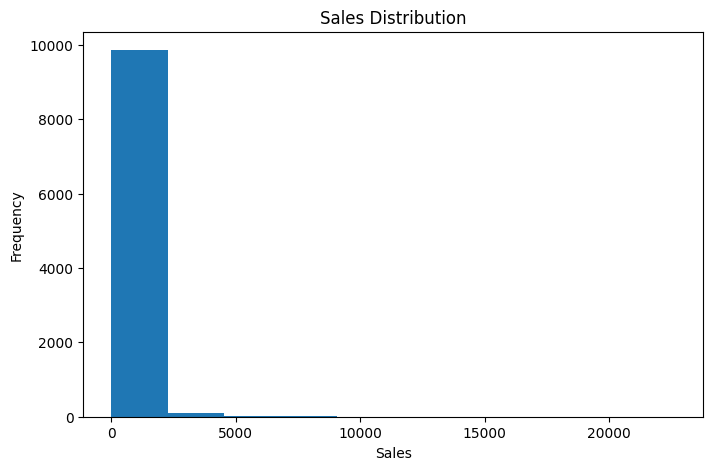

In [59]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

<p style="font-size: 28px;">Observation</p>

The histogram shows that most sales values are concentrated in the lower range, while few transactions have very high sales values.

<p style="font-size: 28px;">Category Analysis</p>

A count plot was created to visualize the distribution of records across different product categories.

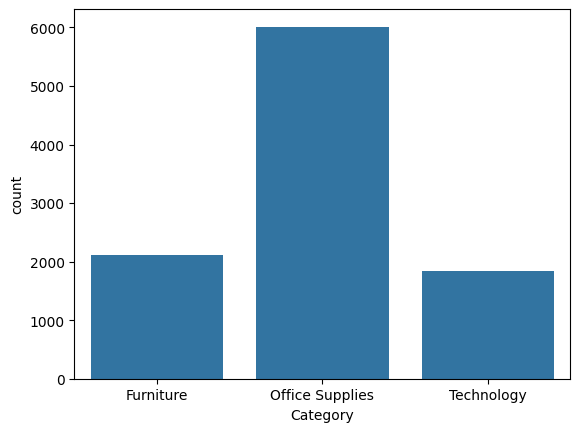

In [60]:
sns.countplot(
    x='Category',
    data=df
)

plt.show()

<p style="font-size: 28px;">Observation</p>

Technology category has the highest number of records in the dataset.

<p style="font-size: 28px;">Region-wise Sales Analysis</p>

A bar plot was created to compare total sales across different regions.

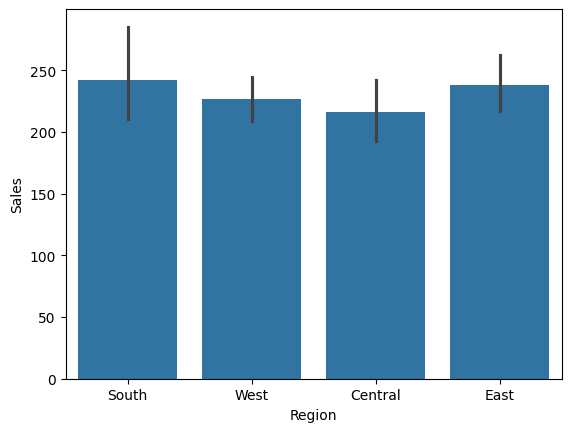

In [61]:
sns.barplot(
    x='Region',
    y='Sales',
    data=df
)

plt.show()

<p style="font-size: 28px;">Observation</p>

Sales vary across regions, indicating differences in market performance and demand.

<p style="font-size: 28px;">Profit Distribution Analysis</p>

A boxplot was created to understand the distribution of profit values and detect outliers in the dataset.

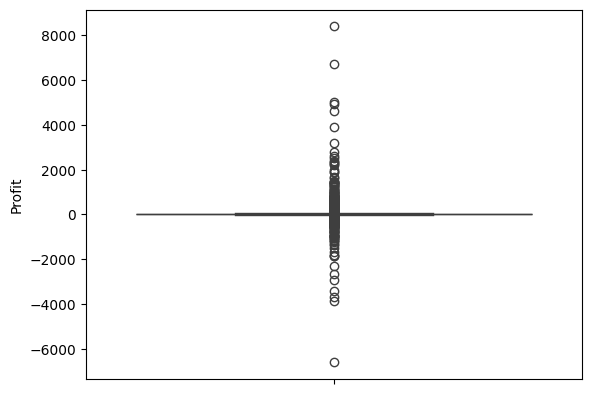

In [62]:
sns.boxplot(
    y='Profit',
    data=df
)

plt.show()

<p style="font-size: 28px;">Observation</p>

The boxplot shows presence of outliers in profit values, indicating that some transactions generated unusually high or low profits.

<p style="font-size: 28px;">Correlation Analysis</p>

Correlation analysis was performed to understand the relationship between Sales, Profit, Quantity, and Discount.

In [63]:
df[['Sales','Profit','Quantity','Discount']].corr()

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479067,0.200722,-0.028311
Profit,0.479067,1.000000,0.066211,-0.219662
Quantity,0.200722,0.066211,1.000000,0.008678
Discount,-0.028311,-0.219662,0.008678,1.000000


<p style="font-size: 28px;">Heatmap Analysis</p>

A heatmap was used to visually represent the correlation between numerical variables.



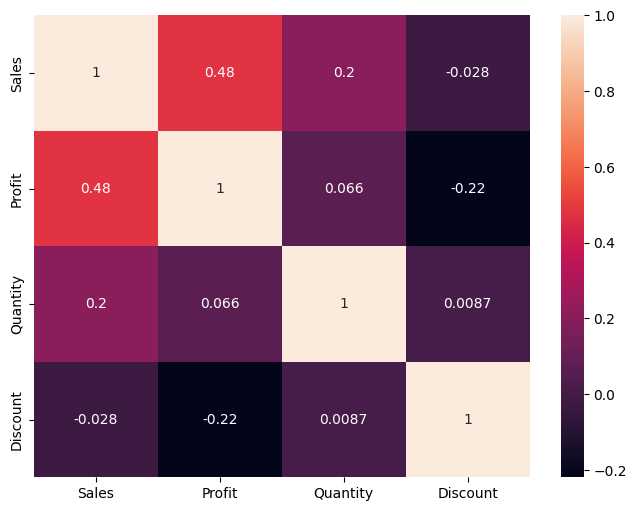

In [64]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Sales','Profit','Quantity','Discount']].corr(),
    annot=True
)

plt.show()

<p style="font-size: 28px;">Observation</p>

The heatmap shows a positive correlation between Sales and Profit, while Discount shows a negative correlation with Profit, indicating that higher discounts reduce profitability.

<p style="font-size: 28px;">Time Series Analysis </p>

A time series analysis was performed to understand monthly sales trends. A date column was created and sales were aggregated by month.



<p style="font-size: 28px;">kDE + Skewness Analysis</p>

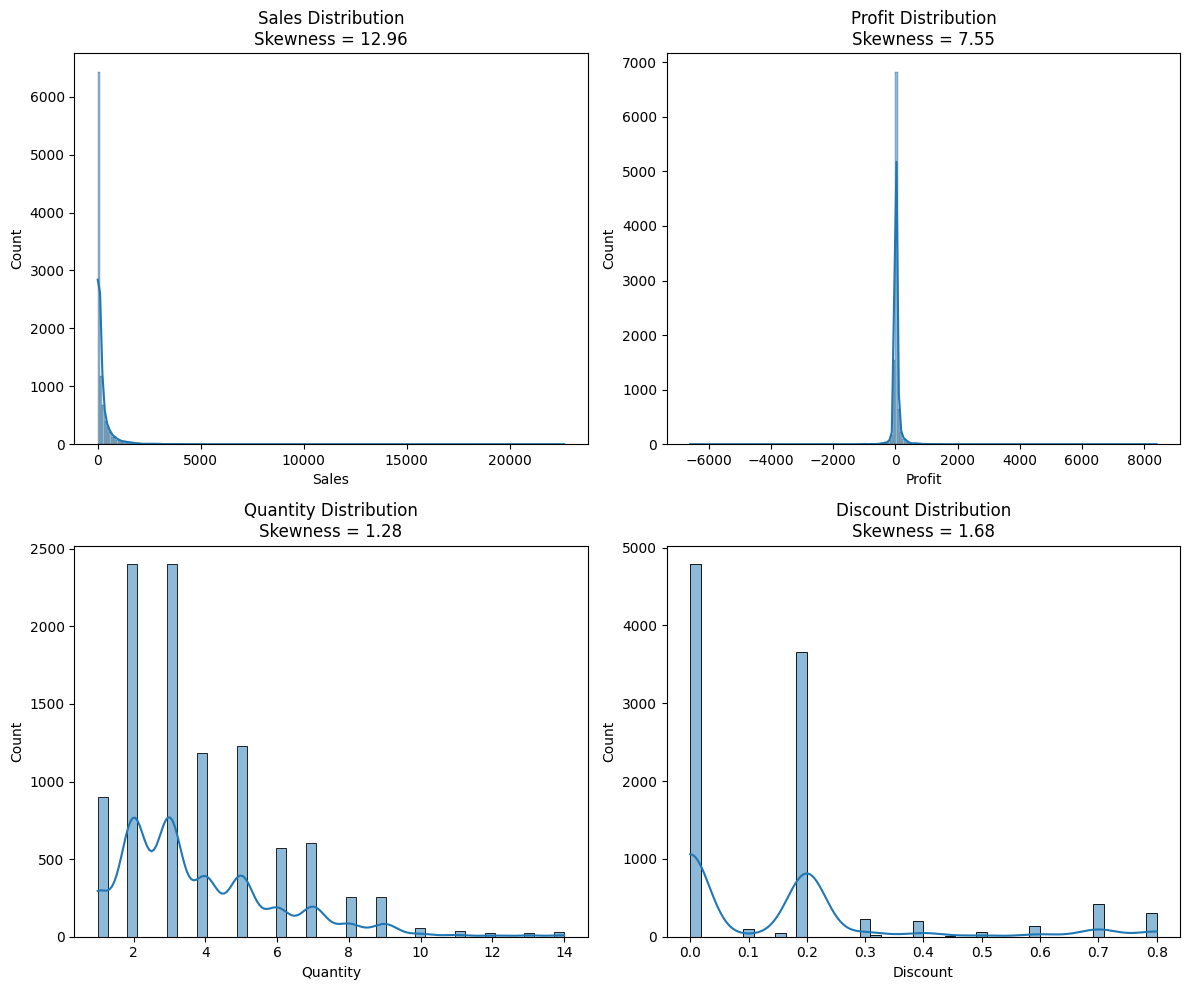

In [65]:
# KDE and Distribution Analysis

numerical_cols = ['Sales', 'Profit', 'Quantity', 'Discount']

plt.figure(figsize=(12,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution\nSkewness = {df[col].skew():.2f}')

plt.tight_layout()
plt.show()

<p style="font-size: 28px;">Observation</p>
Sales and Profit are likely right-skewed due to a few high-value transactions.

Discount and Quantity tend to have a more concentrated distribution.

Skewness helps identify the presence of extreme values and non-normal distributions.

<p style="font-size: 28px;">Pair Plot Analysis</p>

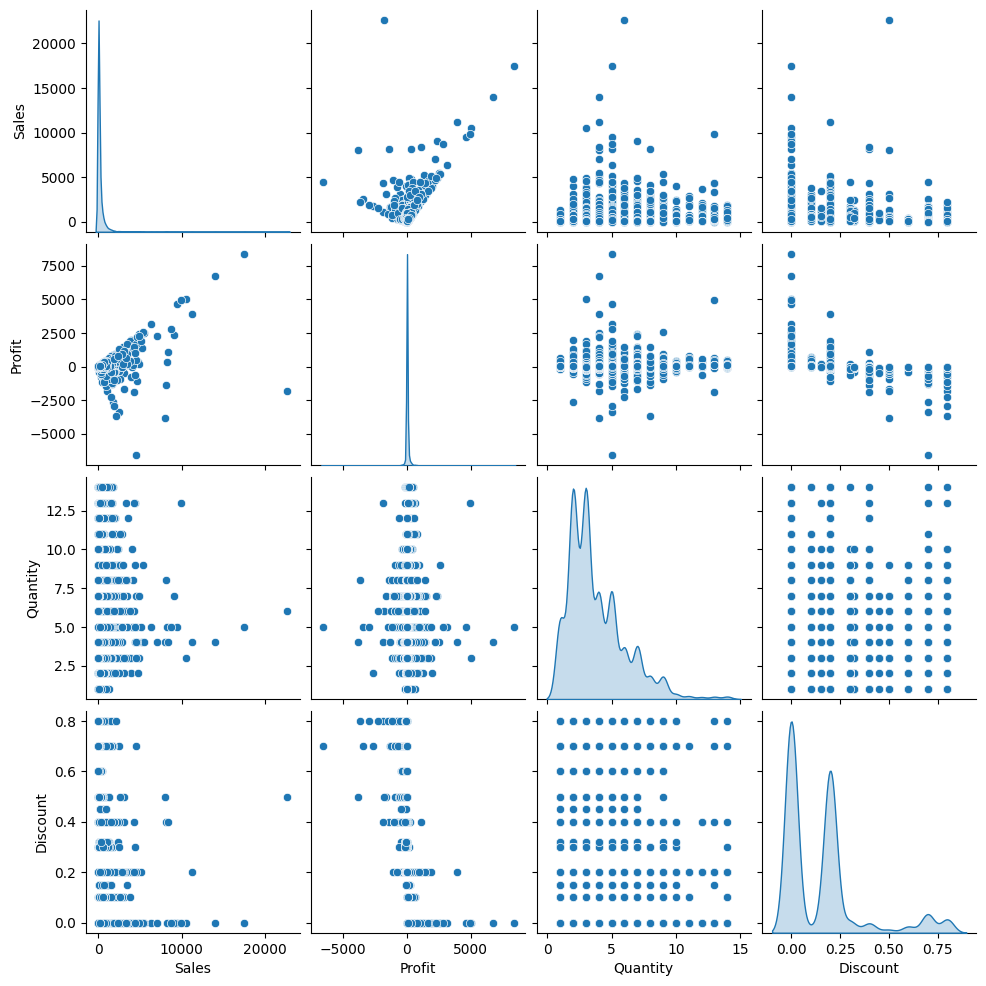

In [66]:
# Pair Plot

sns.pairplot(
    df[['Sales', 'Profit', 'Quantity', 'Discount']],
    diag_kind='kde'
)

plt.show()

<p style="font-size: 28px;">Observation</p>
Sales and Profit show a positive relationship.

Discount appears negatively related to Profit.

Quantity has a weaker relationship with Profit and Sales.

Useful for detecting trends, clusters, and outliers

<p style="font-size: 28px;">Violin Plot (Profit by Category)</p>

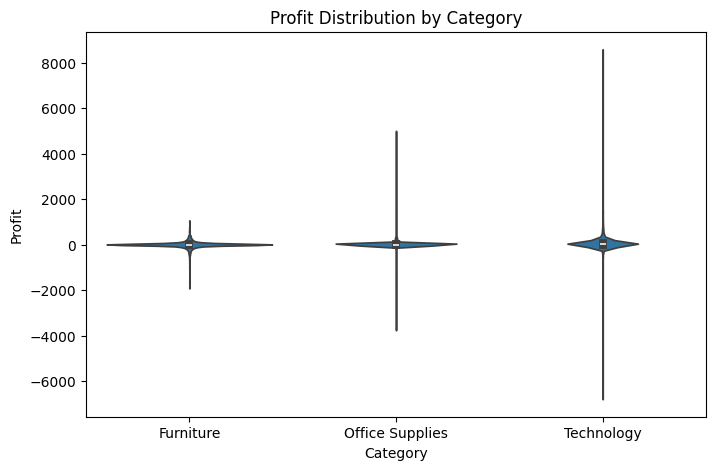

In [67]:
# Profit Distribution Across Categories

plt.figure(figsize=(8,5))

sns.violinplot(
    x='Category',
    y='Profit',
    data=df
)

plt.title('Profit Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

<p style="font-size: 28px;">Observation</p>
Displays the distribution of profits across product categories.

Wider sections indicate higher concentration of transactions.

Reveals variability, median behavior, and potential loss-making categories.

<p style="font-size: 28px;">Sales Distribution by Region (Advanced Violin Plot)</p>

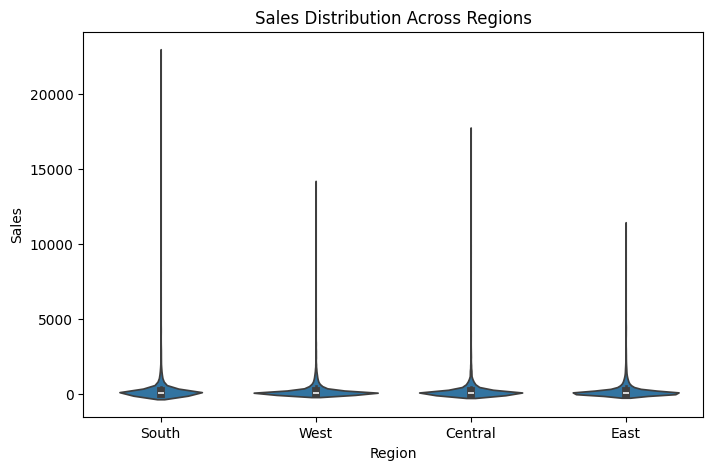

In [68]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Region',
    y='Sales',
    data=df
)

plt.title('Sales Distribution Across Regions')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

<p style="font-size: 28px;">Observation</p>
Helps compare sales spread across regions.

Highlights regions with high-value transactions and variability.

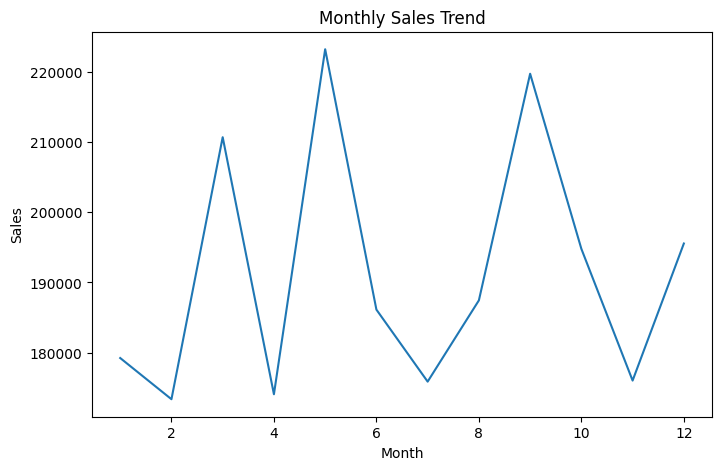

In [69]:
df['OrderDate'] = pd.date_range(
    start='2024-01-01',
    periods=len(df),
    freq='D'
)

monthly_sales = df.groupby(
    df['OrderDate'].dt.month
)['Sales'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(8,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

<p style="font-size: 28px;">Observation</p>

The line chart shows variation in monthly sales, helping to identify trends and seasonal patterns in business performance.

<p style="font-size: 28px;">State-wise Sales Analysis</p>

Top-performing states were identified based on total sales contribution.



In [70]:
df.groupby('State')['Sales'].sum().sort_values(
    ascending=False
).head(10)

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64

<p style="font-size: 28px;">Observation</p>

The analysis shows the top 10 states contributing the highest sales, indicating strong market performance in these regions.

<p style="font-size: 28px;">City-wise Profit Analysis</p>

Top cities were identified based on total profit contribution.


In [71]:

df.groupby('City')['Profit'].sum().sort_values(
    ascending=False
).head(10)

City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Name: Profit, dtype: float64

<p style="font-size: 28px;">Observation</p>

The analysis highlights the top 10 cities generating the highest profit, indicating strong business performance in key urban markets.

<p style="font-size: 28px;">Statistical Analysis</p>

Statistical measures were calculated to understand the central tendency and dispersion of sales data.



In [72]:
print("Mean Sales =", df['Sales'].mean())
print("Median Sales =", df['Sales'].median())
print("Standard Deviation =", df['Sales'].std())
print("Variance =", df['Sales'].var())

Mean Sales = 230.14890150345792
Median Sales = 54.816
Standard Deviation = 623.7214089819952
Variance = 389028.39602248534


<p style="font-size: 28px;">Observation</p>

Mean represents the average sales value across all transactions.
Median shows the central value of sales distribution.
Standard deviation indicates how spread out the sales values are.
Variance measures the overall variability in sales data.




In [73]:
df.drop_duplicates(inplace=True)

In [74]:
# Save cleaned dataset
df.to_csv("superstore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


<p style="font-size: 28px;">Hypothesis Testing</p>

A Pearson correlation test was performed to analyze the relationship between Discount and Profit.

In [75]:

from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['Discount'],
    df['Profit']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.21966206449082404
P-value: 2.7511675480049978e-109


<p style="font-size: 30px;">Hypothesis Explanation</p>

<p style="font-size: 28px;">Null Hypothesis (H0):</p> There is no meaningful relationship between Discount and Profit.

<p style="font-size: 28px;">Alternative Hypothesis (H1):</p> There exists a significant relationship between Discount and Profit.
 Business Insights

From the analysis, several important patterns were identified that help understand overall business performance and customer behavior.

 <p style="font-size: 30px;">Key Findings</p>

The West region recorded the highest overall sales compared to other regions.
The Technology category contributed the highest total profit.
Higher discounts were associated with lower profitability, indicating a negative impact on profit margins.
Certain sub-categories showed consistent losses, suggesting a need for product-level review and improvement.
The Consumer segment contributed the largest share of total sales.
Profit Margin analysis revealed variations in efficiency across transactions, helping evaluate how effectively sales are converted into profit.

<p style="font-size: 30px;"> Business Recommendations</p>

Based on the insights obtained from the dataset, the following strategies are suggested to improve overall performance and profitability.

<p style="font-size: 30px;"> Key Recommendations</p>

Increase focus on Technology products as they consistently generate higher profits.
Strengthen sales strategies in weaker regions such as the South to improve performance balance.
Re-evaluate discount policies to ensure they do not significantly reduce profit margins.
Expand business operations in high-performing states like California and New York.
Address underperforming sub-categories by optimizing pricing, marketing, or product mix

<p style="font-size: 30px;">ADVANCED SQL</p>

<p style="font-size: 25px;">Top 5 States by Sales Performance</p>

SELECT State,

       SUM(Sales) AS TotalSales

FROM Superstore

GROUP BY State

ORDER BY TotalSales DESC

LIMIT 5;

This query aggregates total sales for each state and then ranks them in descending order to identify the highest revenue-generating regions.


<p style="font-size: 25px;">Profit Distribution Across Product Categories</p>

SELECT Category,

       SUM(Profit) AS TotalProfit

FROM Superstore

GROUP BY Category;


This helps in understanding which product categories contribute most to overall profitability by summing up profits at category level.


<p style="font-size: 25px;">Regional Sales Contribution</p>

SELECT Region,

       SUM(Sales) AS TotalSales

FROM Superstore

GROUP BY Region;

This query evaluates how each geographical region contributes to total sales performance.

<p style="font-size: 30px;">SQL Insights Summary</p>

SQL-based analysis was used to extract structured business insights through aggregation and grouping operations. 
It helped in identifying top-performing states, profitable product categories, and high-revenue regions.

<p style="font-size: 30px;">Key Observations

The West region showed the strongest sales performance overall.

Technology products generated the highest profit contribution.

California emerged as the leading state in terms of revenue.

The Consumer segment accounted for the largest share of total sales.

<p style="font-size: 30px;">Excel Data Validation Stage</p>

Before performing analysis in Python, the Superstore dataset was reviewed in Microsoft Excel.

Verified column names and data structure
Checked for missing values and duplicate records
Performed preliminary data validation
Reviewed sales and profit data consistency
Excel was used as a preliminary data inspection tool before advanced analysis using Python and Power BI.

<p style="font-size: 30px;">Activities performed:</p>

Checked dataset structure and column correctness

Verified presence of missing or inconsistent values

Identified duplicate or redundant entries

Validated sales and profit fields for accuracy

This step ensured the dataset was clean and ready for advanced analytical processing.

<p style="font-size: 30px;">Power BI Dashboard Development</p>

An interactive Power BI dashboard was developed to visualize:

Sales by Region
Sales by Segment
Profit by Category
Top States by Sales
Total Sales KPI
Total Profit KPI
The dashboard provides a visual summary of business performance and supports data-driven decision-making.

<p style="font-size: 30px;">Dashboard Components:</p>

Sales distribution across regions

Segment-wise sales comparison

Profit contribution by category

Top-performing states based on sales

Key KPI indicators for sales and profit

This dashboard helped convert raw data into a visual storytelling format for easier business interpretation.

<p style="font-size: 33px;">Final Conclusion</p>
This project successfully analyzed retail sales data using Python, Pandas, NumPy, SQL, Microsoft Excel, and Power BI to uncover valuable business insights.

The analysis covered data cleaning, exploratory data analysis, statistical analysis, hypothesis testing, feature engineering, time series analysis, SQL-based business analysis, and interactive dashboard development.

The findings revealed key sales and profit trends across regions, categories, states, and customer segments. The study also highlighted the impact of discount strategies on profitability and identified high-performing business areas.

Overall, this project demonstrates how data analytics techniques can transform raw business data into meaningful insights, enabling organizations to make informed decisions, improve profitability, and support long-term business growth.